Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library(tidymodels)


-- Attaching packages -------------------------------------- tidymodels 1.4.1 --

v broom        1.0.13     v recipes      1.3.3 
v dials        1.4.4      v rsample      1.3.2 
v dplyr        1.2.1      v tailor       0.1.0 
v ggplot2      4.0.3      v tidyr        1.3.2 
v infer        1.1.0      v tune         2.0.1 
v modeldata    1.5.1      v workflows    1.3.0 
v parsnip      1.6.0      v workflowsets 1.1.1 
v purrr        1.2.2      v yardstick    1.4.0 

-- Conflicts ----------------------------------------- tidymodels_conflicts() --
x purrr::discard() masks scales::discard()
x dplyr::filter()  masks stats::filter()
x dplyr::lag()     masks stats::lag()
x recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [3]:
glimpse(diabetes_train)



Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 10, 4, 10, 1, 3, 8, 1, 13, 5, 5, 3, 6, 10,~
$ Glucose                  <dbl> 89, 115, 110, 139, 103, 126, 99, 97, 145, 117~
$ BloodPressure            <dbl> 66, 0, 92, 80, 30, 88, 84, 66, 82, 92, 75, 58~
$ SkinThickness            <dbl> 23, 0, 0, 0, 38, 41, 0, 15, 19, 0, 26, 11, 0,~
$ Insulin                  <dbl> 94, 0, 0, 0, 83, 235, 0, 140, 110, 0, 0, 54, ~
$ BMI                      <dbl> 28.1, 35.3, 37.6, 27.1, 43.3, 39.3, 35.4, 23.~
$ DiabetesPedigreeFunction <dbl> 0.167, 0.134, 0.191, 1.441, 0.183, 0.704, 0.3~
$ Age                      <dbl> 21, 29, 30, 57, 33, 27, 50, 22, 57, 38, 60, 2~
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ~


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

Outcome

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Oral glucose tolerance test - OGTT (two hour plasma glucose concentration after 75g anhydrous glucose in mg/dl)           |
| BMI         |  Body Mass Index in kg/m2           |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

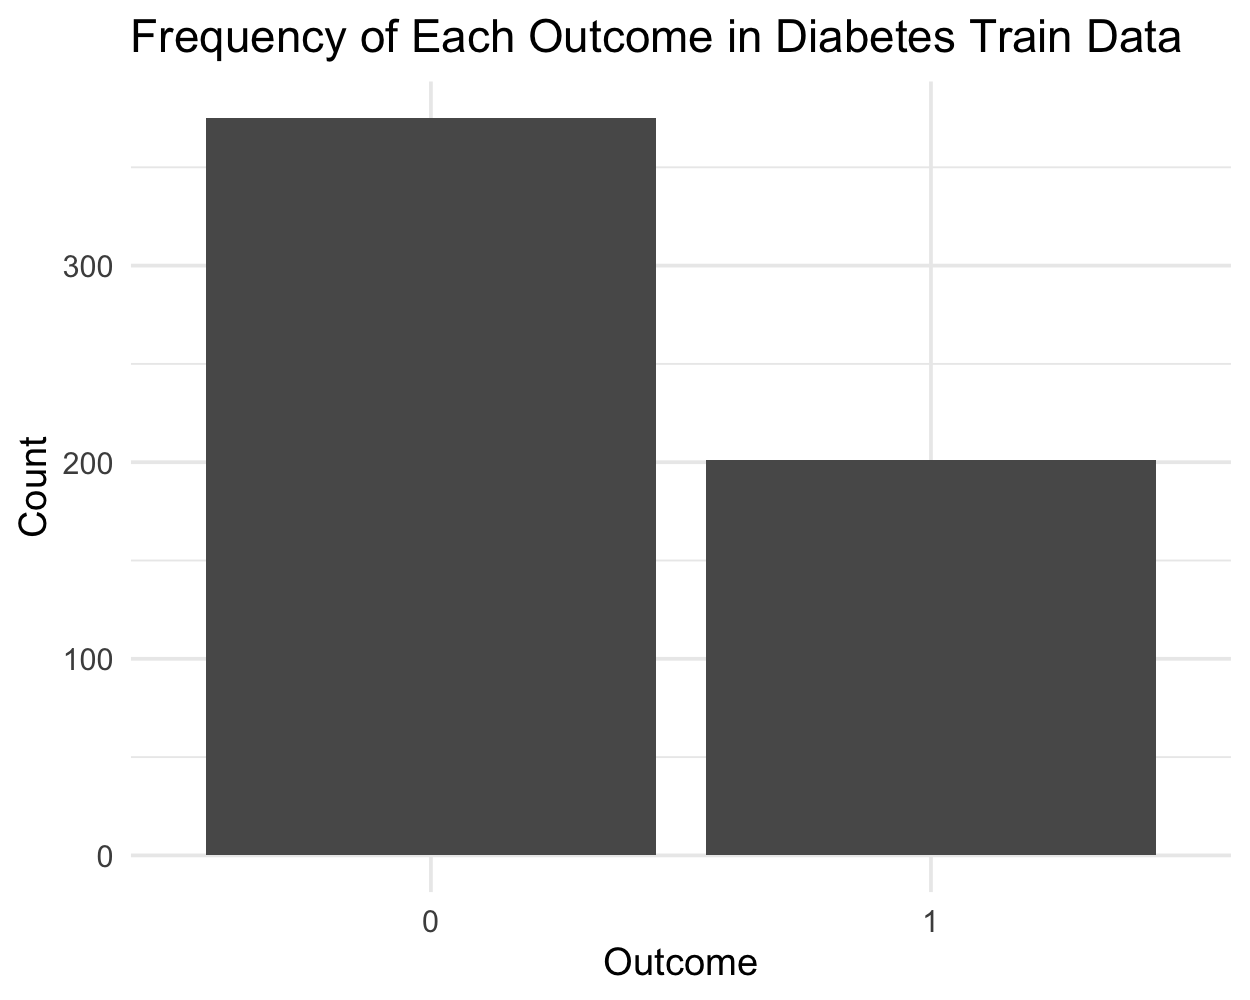

In [4]:
ggplot(diabetes_train, aes(x = Outcome)) +
  geom_bar() +
  labs(title = "Frequency of Each Outcome in Diabetes Train Data",
       x = "Outcome",
       y = "Count") +
  theme_minimal()

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

Data is not balanced, there are more data points with Outcome being 0.



Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [5]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,89.0
0,BMI,28.1
0,Glucose,115.0
0,BMI,35.3
0,Glucose,110.0
0,BMI,37.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

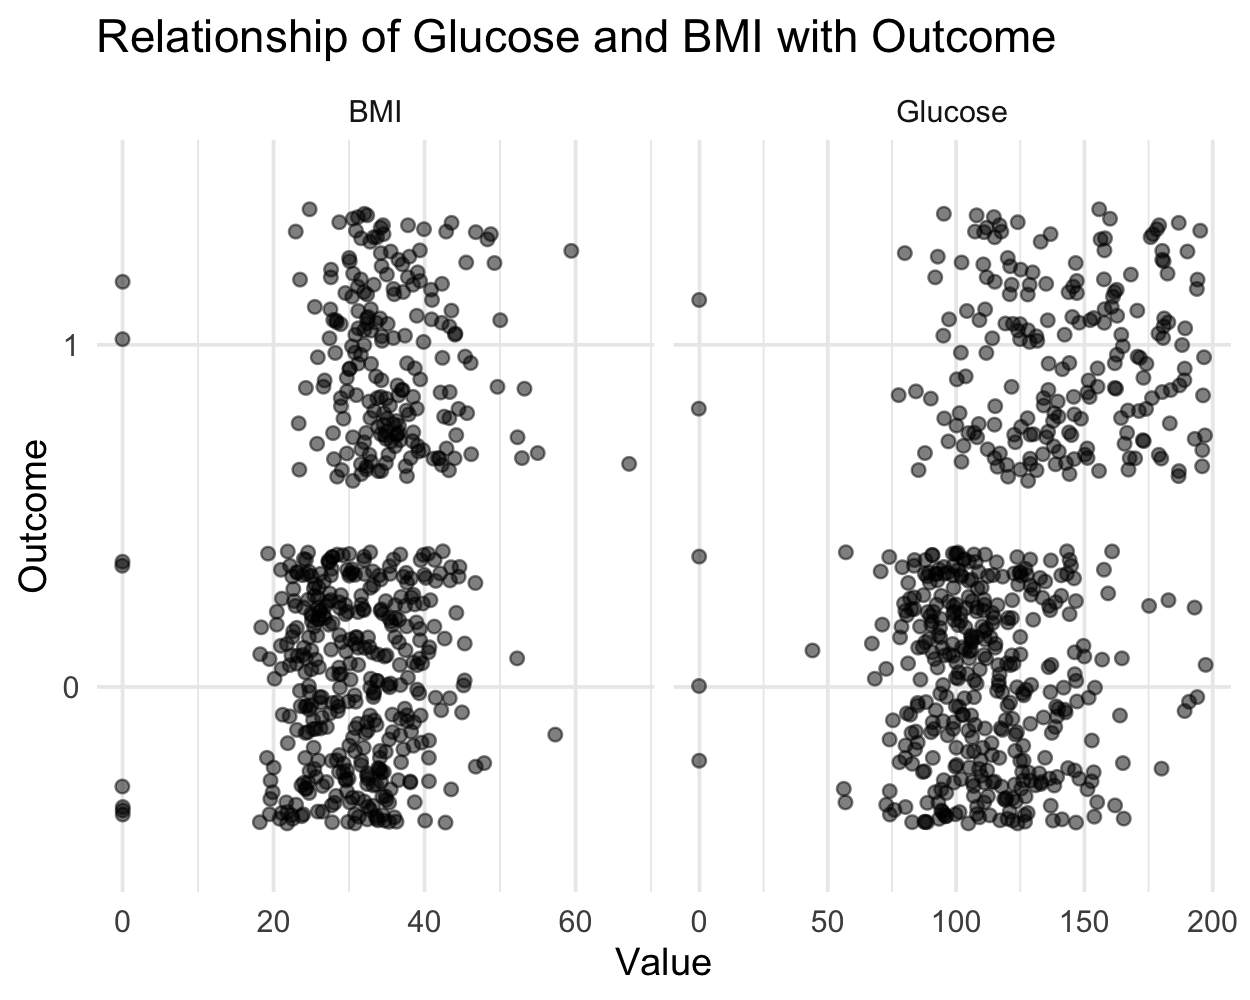

In [6]:

plot_df |>
  ggplot(aes(x = value, y = Outcome)) +
  geom_jitter(alpha = 0.5) +
  facet_wrap(~name, ncol = 2, scales = 'free_x') +
  labs(title = "Relationship of Glucose and BMI with Outcome",
       x = "Value",
       y = "Outcome") +
  theme_minimal()


❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

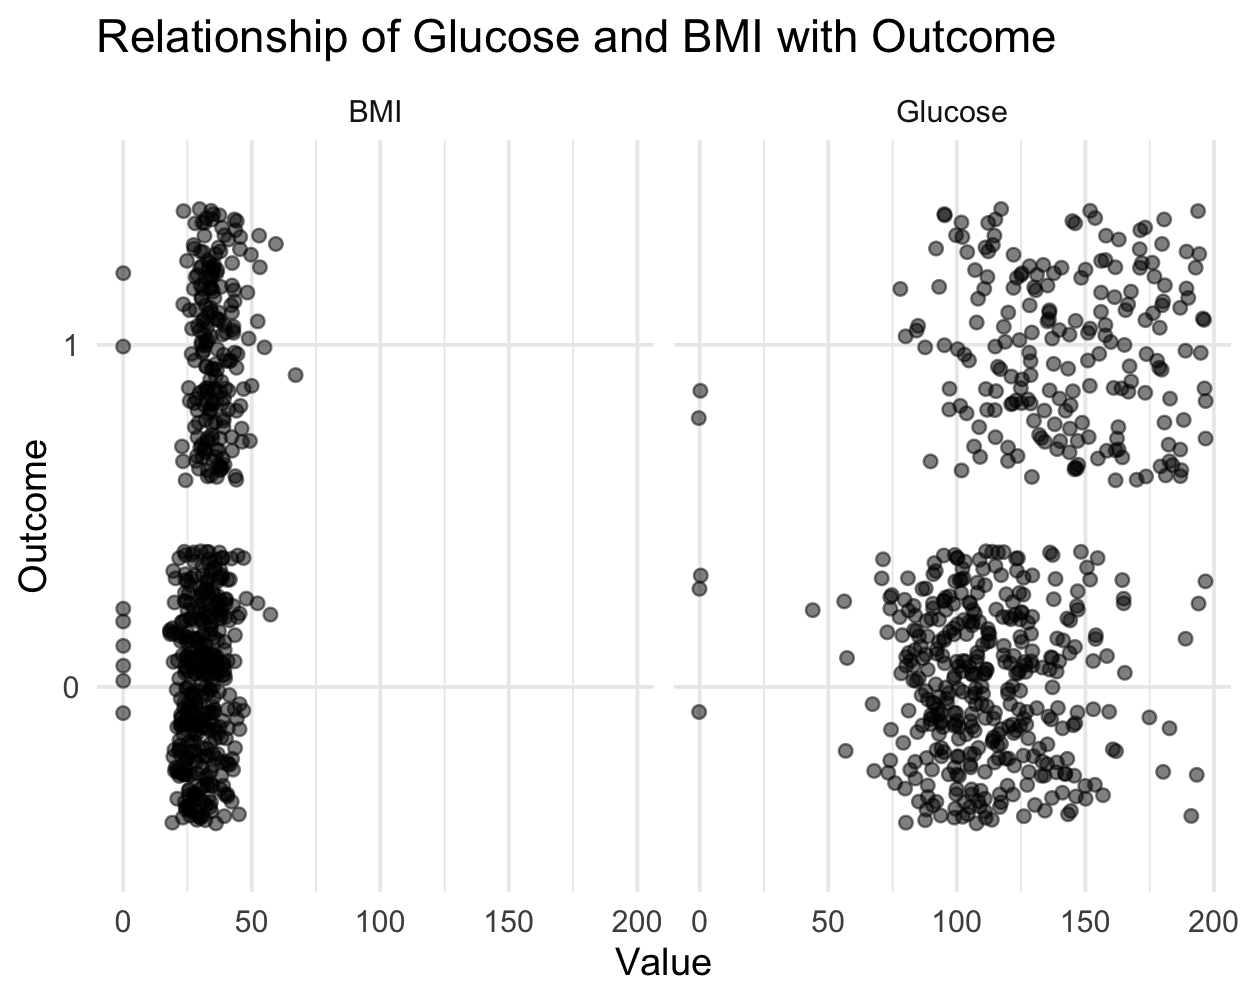

In [7]:
plot_df |>
  ggplot(aes(x = value, y = Outcome)) +
  geom_jitter(alpha = 0.5) +
  facet_wrap(~name, ncol = 2) +
  labs(title = "Relationship of Glucose and BMI with Outcome",
       x = "Value",
       y = "Outcome") +
  theme_minimal()

In [8]:
The free_x scales in the previous plot allow each facet to have its own x-axis range.
This has the advantage of making it easier to see the distribution of each variable within its own range. 
With the free_x flag, the BMI previously had a range of 0 - 65, on removing the free_x flag,
 the BMI range is now 0 - 200, which makes it harder to see the distribution of BMI values.


ERROR: Error in parse(text = input): <text>:1:5: unexpected symbol
1: The free_x
        ^


Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [ ]:
mod_fit = logistic_reg() |>
  set_engine("glm") |>
  fit(Outcome ~ BMI + Glucose, data = diabetes_train)
  



Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [ ]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [ ]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 113  31
         1  12  36

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

In [ ]:
individuals_with_diabetes = diabetes_test |> filter(Outcome == "1") |> nrow()
print(paste("Number of individuals with diabetes in test data:", individuals_with_diabetes))

individuals_with_diabetes_and_predicted = diabetes_test_wPred |> filter(Outcome == "1" & .pred_1 > 0.5) |> nrow()
print(paste("Number of individuals with diabetes predicted by the model:", individuals_with_diabetes_and_predicted))

individuals_predicted_without_diabetes = diabetes_test_wPred |> filter(.pred_1 > 0.5 & Outcome == "0") |> nrow()
print(paste("Number of individuals predicted to have diabetes but without it:", individuals_predicted_without_diabetes))

[1] "Number of individuals with diabetes in test data: 67"
[1] "Number of individuals with diabetes predicted by the model: 36"
[1] "Number of individuals predicted to have diabetes but without it: 12"
